## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

### Importy

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    recall_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    make_scorer
)

### Wczytanie Danych

In [89]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
from pathlib import Path

DATA_FILE = Path("/content/drive/MyDrive/datasets/agaricus-lepiota.data")

COLUMNS = [
    "poisonous",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat",
]

df = pd.read_csv(DATA_FILE, header=None, names=COLUMNS, na_values="?")
X = df.drop(columns=["poisonous"])
y = df[["poisonous"]]

print(f"Wczytano: {DATA_FILE}")
print(f"X: {X.shape}, y: {y.shape}")
print(y["poisonous"].value_counts()) 

Wczytano: /content/drive/MyDrive/datasets/agaricus-lepiota.data
X: (8124, 22), y: (8124, 1)
poisonous
e    4208
p    3916
Name: count, dtype: int64


### Walidacja danych

- Sprawdzanie braków

In [91]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

In [92]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   poisonous  8124 non-null   object
dtypes: object(1)
memory usage: 63.6+ KB


In [93]:
X.isnull().sum()


,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0
stalk-shape,0


- Są braki w stalk-root

### Opis Zmiennych (Mushroom Dataset)

Wszystkie zmienne w tym zbiorze są typu kategorycznego (zapisane za pomocą pojedynczych liter).

| Nazwa Kolumny | Opis (pl) | Przyjmowane wartości (klucz) |
| :--- | :--- | :--- |
| **poisonous** | **ZMIENNA CELU:** Czy grzyb jest trujący? | e = jadalny (edible), p = trujący (poisonous) |
| **cap-shape** | Kształt kapelusza | b=dzwonkowaty, c=stożkowy, x=wypukły, f=płaski, k=garbaty, s=wklęsły |
| **cap-surface** | Powierzchnia kapelusza | f=włóknista, g=żłobiona, y=łuskowata, s=gładka |
| **cap-color** | Kolor kapelusza | n=brązowy, b=płowy, c=cynamonowy, g=szary, r=zielony, p=różowy, u=fioletowy, e=czerwony, w=biały, y=żółty |
| **bruises** | Czy po uciśnięciu sinieje? | t=tak, f=nie |
| **odor** | Zapach | a=migdałowy, l=anyżowy, c=kreozotowy, y=rybi, f=cuchnący, m=stęchły, n=brak zapachu, p=ostry, s=przypraw |
| **gill-attachment** | Sposób przyrostu blaszek | a=przyrośnięte, d=zbiegające, f=wolne, n=wycięte |
| **gill-spacing** | Rozstaw blaszek | c=blisko, w=gęste, d=rzadkie |
| **gill-size** | Rozmiar blaszek | b=szerokie, n=wąskie |
| **gill-color** | Kolor blaszek | k=czarny, n=brązowy, b=płowy, h=czekoladowy, g=szary, r=zielony, o=pomarańczowy, p=różowy, u=fioletowy, e=czerwony, w=biały, y=żółty |
| **stalk-shape** | Kształt trzonu | e=rozszerzający się, t=zwężający się |
| **stalk-root** | Korzeń trzonu (Tu występuje dużo braków "NaN") | b=bulwiasty, c=maczugowaty, u=kubkowaty, e=równy, z=ryzomorficzny, r=ukorzeniony, ?=brak danych |
| **stalk-surface-above-ring** | Powierzchnia trzonu (nad pierścieniem) | f=włóknista, y=łuskowata, k=jedwabista, s=gładka |
| **stalk-surface-below-ring** | Powierzchnia trzonu (pod pierścieniem) | f=włóknista, y=łuskowata, k=jedwabista, s=gładka |
| **stalk-color-above-ring** | Kolor trzonu (nad pierścieniem) | n=brązowy, b=płowy, c=cynamonowy, g=szary, o=pomarańczowy, p=różowy, e=czerwony, w=biały, y=żółty |
| **stalk-color-below-ring** | Kolor trzonu (pod pierścieniem) | n=brązowy, b=płowy, c=cynamonowy, g=szary, o=pomarańczowy, p=różowy, e=czerwony, w=biały, y=żółty |
| **veil-type** | Typ osłony | p=częściowa, u=całkowita |
| **veil-color** | Kolor osłony | n=brązowy, o=pomarańczowy, w=biały, y=żółty |
| **ring-number** | Liczba pierścieni | n=brak, o=jeden, t=dwa |
| **ring-type** | Typ pierścienia | c=pajęczynowaty, e=zanikający, f=odstający, l=duży, n=brak, p=zwisający, s=pochwiasty, z=strefowy |
| **spore-print-color** | Kolor wysypu zarodników | k=czarny, n=brązowy, b=płowy, h=czekoladowy, r=zielony, o=pomarańczowy, u=fioletowy, w=biały, y=żółty |
| **population** | Występowanie (populacja) | a=obfite, c=skupione, n=liczne, s=rozproszone, v=kilka, y=pojedyncze |
| **habitat** | Środowisko (siedlisko) | g=trawy, l=liście, m=łąki, p=ścieżki, u=miejskie, w=nieużytki, d=lasy |

- Jako główną metrykę ewaluacji wybieram Recall, ze względu na to, że śmierć potencjalnego człowieka jest tragiczna w skutkach i lepiej nawet mieć fałszywe alarmy, niż przeoczyć zatrucie zagrażające życiu.

In [94]:
X = X.copy()
X["stalk-root"] = X["stalk-root"].fillna("Missing")

- Zastąpiłem braki w `stalk-root` kategorią `Missing`.

In [95]:
assert X.duplicated().sum() == 0

- Nie ma duplikatów

### Zastosowanie `One Hot Encodingu` ze względu na to , że dane są zmiennymi nominalnymi kategorycznymi


In [96]:
X = X.copy()
X = pd.get_dummies(X, drop_first = True)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 95 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   cap-shape_c                 8124 non-null   bool 
 1   cap-shape_f                 8124 non-null   bool 
 2   cap-shape_k                 8124 non-null   bool 
 3   cap-shape_s                 8124 non-null   bool 
 4   cap-shape_x                 8124 non-null   bool 
 5   cap-surface_g               8124 non-null   bool 
 6   cap-surface_s               8124 non-null   bool 
 7   cap-surface_y               8124 non-null   bool 
 8   cap-color_c                 8124 non-null   bool 
 9   cap-color_e                 8124 non-null   bool 
 10  cap-color_g                 8124 non-null   bool 
 11  cap-color_n                 8124 non-null   bool 
 12  cap-color_p                 8124 non-null   bool 
 13  cap-color_r                 8124 non-null   bool 
 14  cap-colo

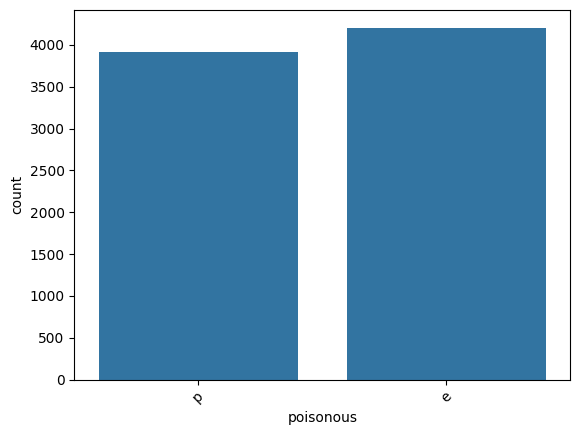

In [97]:
sns.countplot(x= 'poisonous', data = y)
plt.xticks(rotation = 45)
plt.show()

- Zmienna celu jest zbilansowa, więc nie trzeba jej modyfikować, jedynie zmapować pod późniejsze obliczenia.

In [98]:
y = y.copy()
y = y["poisonous"].map({"e": 0, "p": 1})

### Badanie korelacji

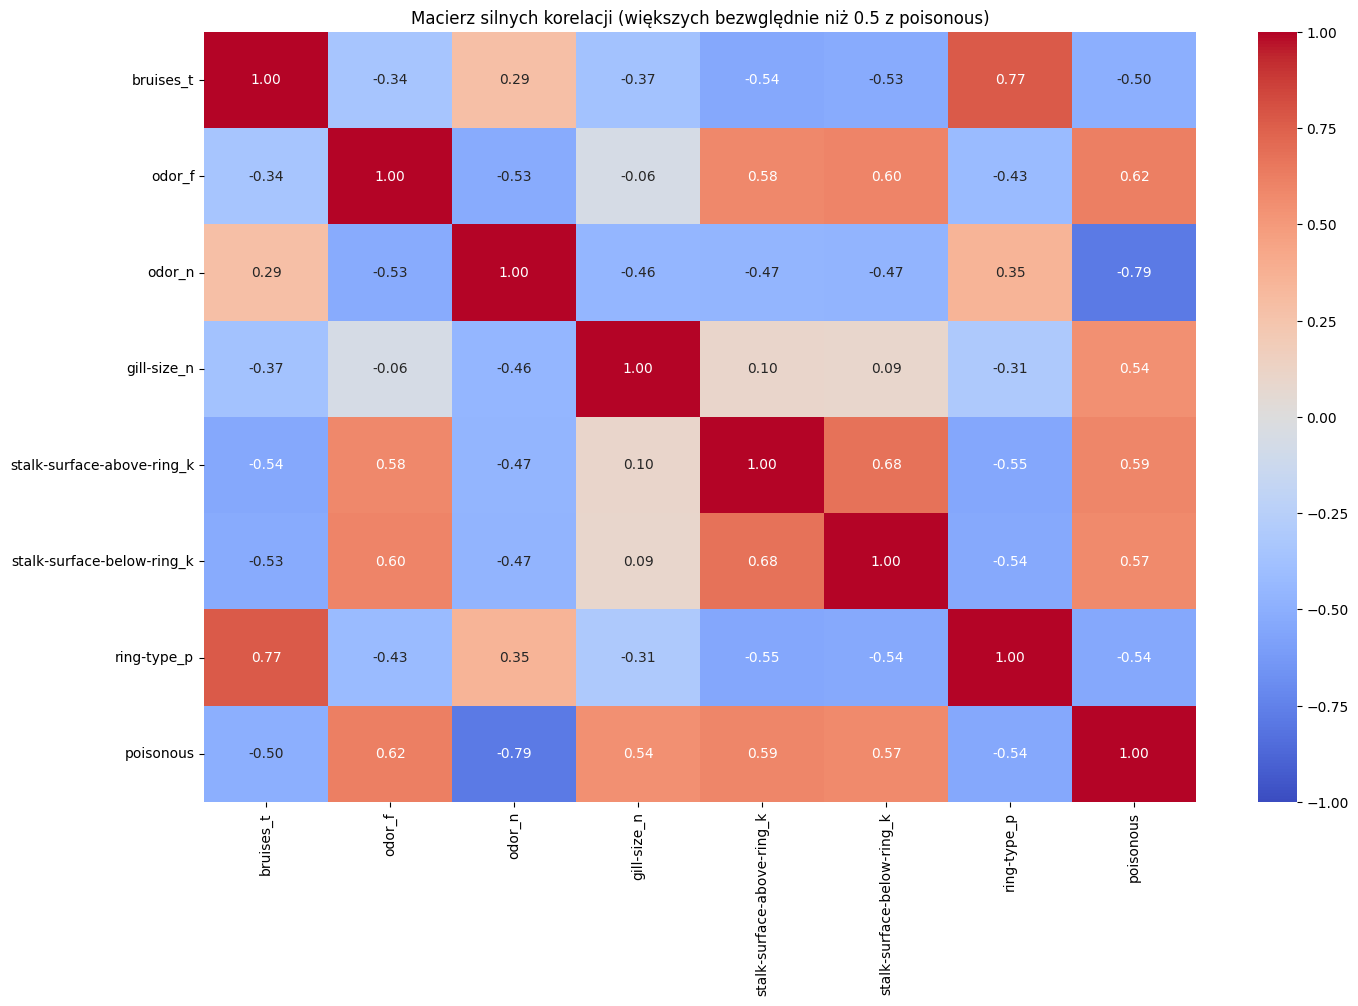

In [99]:
plt.figure(figsize = (16, 10))
encoded = pd.concat([X,y], axis = 1)
corr = encoded.corr()
target_corr = corr["poisonous"]
significant_corr = target_corr[target_corr.abs() > 0.5].index.tolist()
sns.heatmap(corr.loc[significant_corr, significant_corr], vmin = -1, vmax = 1, cmap = "coolwarm", annot = True, fmt = ".2f")
plt.title("Macierz silnych korelacji (większych bezwględnie niż 0.5 z poisonous)")
plt.show()

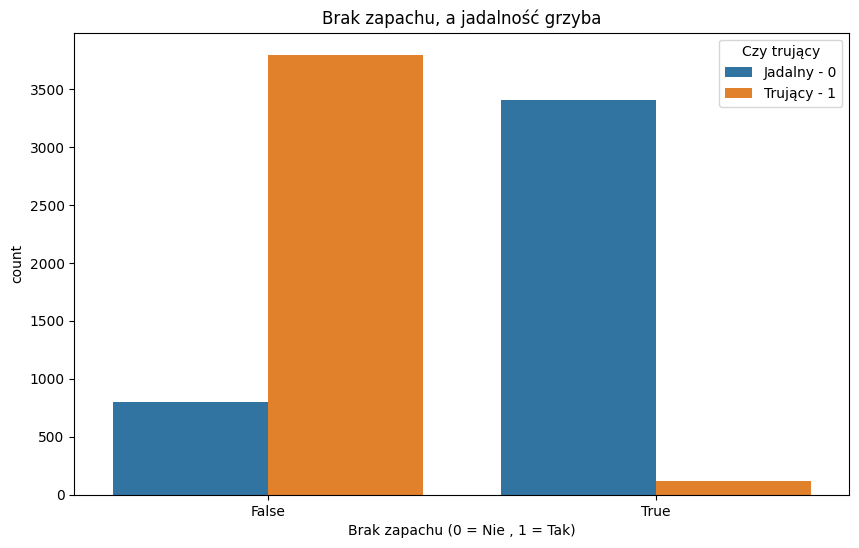

In [100]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'odor_n', hue = 'poisonous', data = encoded)
plt.title("Brak zapachu, a jadalność grzyba")
plt.xlabel("Brak zapachu (0 = Nie , 1 = Tak)")
plt.legend(title = "Czy trujący", labels = ['Jadalny - 0', 'Trujący - 1'])
plt.show()

- Występuje korelacja: brak zapachu wystąpi raczej u jadalnego grzyba, niż u trującego.

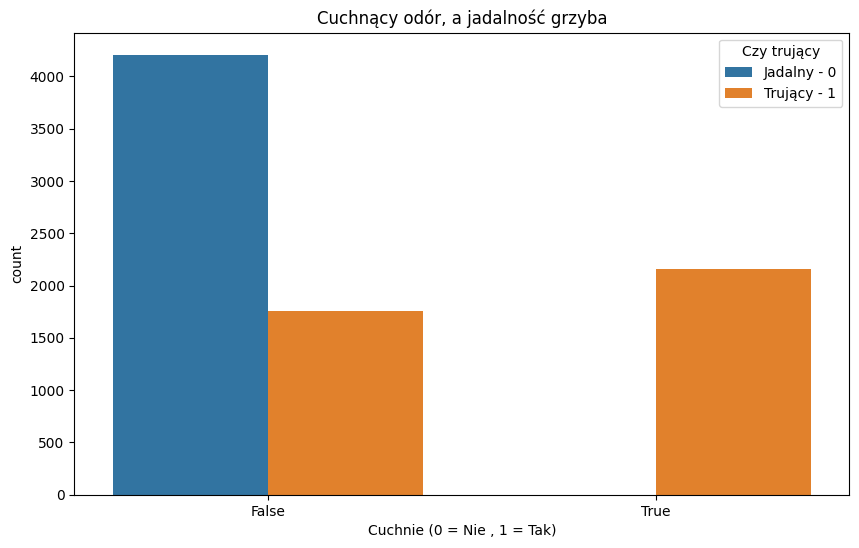

In [101]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'odor_f', hue = 'poisonous', data = encoded)
plt.title("Cuchnący odór, a jadalność grzyba")
plt.xlabel("Cuchnie (0 = Nie , 1 = Tak)")
plt.legend(title = "Czy trujący", labels = ['Jadalny - 0', 'Trujący - 1'])
plt.show()

- Jak grzyb cuchnie, to raczej jest trujący.

### Podział danych


In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 67, stratify = y)

### Baseline

In [103]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        y_score = y_pred
        roc_auc = None
    
    return {
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": average_precision_score(y_test, y_score),
    }


In [104]:
baseline_models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "dummy_stratified": DummyClassifier(strategy="stratified", random_state=42),
    "logreg_default": LogisticRegression(max_iter=2000, random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state = 42)
}

rows = []
for name, model in baseline_models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    metrics["model"] = name
    rows.append(metrics)

baseline_results = pd.DataFrame(rows)[
    ["model", "recall","f2", "precision" , "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)

baseline_results

,model,recall,f2,precision,roc_auc,pr_auc
3,decision_tree,1.000000,1.000000,1.000000,1.000000,1.000000
2,logreg_default,0.997446,0.997956,1.000000,1.000000,1.000000
1,dummy_stratified,0.498084,0.496183,0.488722,0.506762,0.485271
0,dummy_most_frequent,0.000000,0.000000,0.000000,0.500000,0.481846


- Regresja logistyczna oraz drzewo decyzyjne osiągnęły około stuprocentowe wyniki.

### Bagging z GridSearchem

In [105]:
bagging = BaggingClassifier(
    estimator = DecisionTreeClassifier(random_state = 42),
    random_state = 42
)

param_grid = {
    'n_estimators': [10,20,30,50,100],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}


grid_search = GridSearchCV(
    estimator = bagging,
    param_grid = param_grid,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1
)


grid_search.fit(X_train, y_train)

best_bagging_model = grid_search.best_estimator_
metrics_bagging = evaluate_model(best_bagging_model, X_train, y_train, X_test, y_test)
metrics_bagging["model"] = "bagging_best_grid"
print("Metryki dla najlepszego Baggingu:")
print(metrics_bagging)


Metryki dla najlepszego Baggingu:
{'recall': 1.0, 'precision': 1.0, 'f2': 1.0, 'roc_auc': np.float64(1.0), 'pr_auc': np.float64(1.0), 'model': 'bagging_best_grid'}


- Dalej się utrzymuje 100 procent.

### GradientBoosting

In [ ]:
gb = GradientBoostingClassifier(random_state = 42)

param_grid = {
    'n_estimators': [10,20,50,100], 
    'learning_rate': [0.05, 0.1, 0.2, 0.5, 1.0],
}

f2_scorer = make_scorer(fbeta_score, beta = 2 , average = "binary")
grid_search = GridSearchCV(
    estimator = gb,
    param_grid = param_grid,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)
best_gb_model = grid_search.best_estimator_
metrics_gb = evaluate_model(best_gb_model, X_train, y_train, X_test, y_test)
metrics_gb["model"] = "gradientboost_best_grid"
print(metrics_gb) 

{'recall': 1.0, 'precision': 1.0, 'f2': 1.0, 'roc_auc': np.float64(1.0), 'pr_auc': np.float64(1.0), 'model': 'gradientboost_best_grid'}


- Również stoprocent.

### VotingClassifier

In [107]:
voting = VotingClassifier(
    estimators = [
        ('logreg', baseline_models["logreg_default"]),
        ('bagging', best_bagging_model),
        ('gradientboosting', best_gb_model)],
    voting = 'soft'
)

metrics_voting = evaluate_model(voting, X_train, y_train , X_test, y_test)
metrics_voting["model"] = "voting"
print(metrics_voting)


{'recall': 1.0, 'precision': 1.0, 'f2': 1.0, 'roc_auc': np.float64(1.0), 'pr_auc': np.float64(1.0), 'model': 'voting'}


- Również 100 procent.

### Ważność cech (Feature Importances)
- Sprawdźmy, na jakiej podstawie modele podejmują decyzje tak skutecznie.

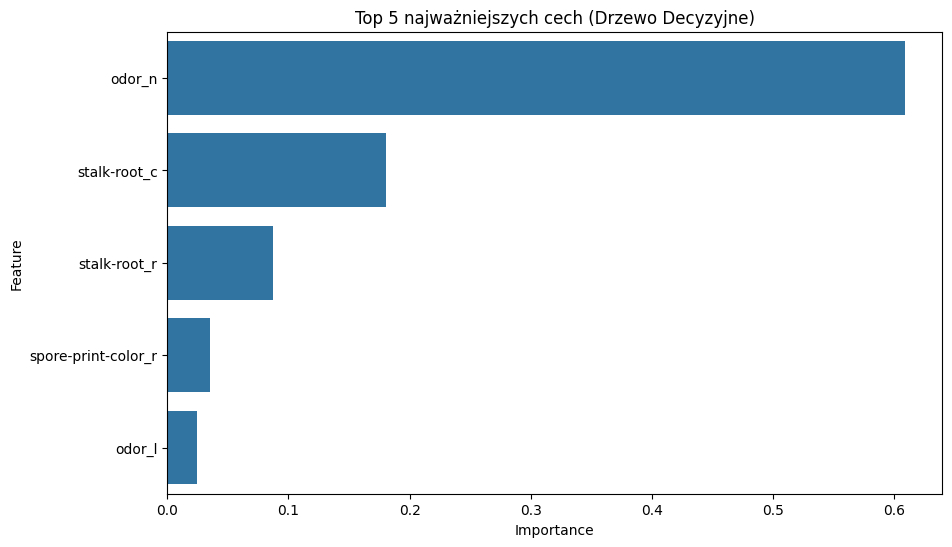

In [113]:
importances = baseline_models["decision_tree"].feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp_df = feat_imp_df.sort_values(by="Importance", ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df)
plt.title("Top 5 najważniejszych cech (Drzewo Decyzyjne)")
plt.show()


### Mierzenie czasu

In [108]:
%%timeit
baseline_models["decision_tree"].predict(X_test)

2.59 ms ± 153 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [109]:
%%timeit
best_bagging_model.predict(X_test)

7.97 ms ± 1.65 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [110]:
%%timeit
best_gb_model.predict(X_test)

6.3 ms ± 598 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [111]:
%%timeit
baseline_models["logreg_default"].predict(X_test)

2.26 ms ± 84.3 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [112]:
%%timeit
voting.predict(X_test)

17.9 ms ± 3.27 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


- Najlepiej czasowo wypada regresja logistyczna. Jej predykcja trwa około 300 mikrosekund, a drugi najszybszy model to zwykły decision tree.

### Wnioski końcowe

- Jako główną miarę wybrałem Recall, ze względu na to, że nie chcemy, by ktoś umarł od zatrucia się grzybem.
- Braki w `stalk-root` zastąpiłem kategorią `Missing`.
- Jeśli chodzi o dane, to należało wykonać `One Hot Encoding` ze względu na to, że było to zmienne nominalne kategoryczne.
- Okazało się , że brak zapachu wystąpi raczej u jadalnego grzyba i że cuchnący grzyb jest raczej trujący.
- Wszystkie modele osiągnęły stuprocentową skuteczność, co sprawia, że użycie cięższych modeli pokroju `Baggingu`, czy `GradientBoostingu` jest marnotrastwem zasobów.
- Wybrałbym ponownie `Regresją Logistyczną`, ponieważ jest najszybsza (szybsza o rzędy wielkości od ciężkich modeli).